In [23]:
!hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/c.txt ~/gpfs/NPM/ncbi_blast_search/C_term_Cnidaria.hmm ~/gpfs/NPM/ncbi_blast_search/BLAST_NPM_ALL.fasta > ~/gpfs/NPM/ncbi_blast_search/NPM_ALL_hmm_search.txt 
!tail -n+4  ~/gpfs/NPM/ncbi_blast_search/c.txt | head -n-10 | awk '{gsub(/ {2,}/, "\t"); print}' > ~/gpfs/NPM/ncbi_blast_search/C_term_Cnidaria.txt

In [38]:
!muscle -align ~/gpfs/NPM/ncbi_blast_search/N-term.fasta -output ~/gpfs/NPM/ncbi_blast_search/N-term.alignment.fasta
!hmmbuild ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm ~/gpfs/NPM/ncbi_blast_search/N-term.alignment.fasta
!hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/n.txt ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm ~/gpfs/NPM/ncbi_blast_search/BLAST_NPM_ALL.fasta > ~/gpfs/NPM/ncbi_blast_search/NPM_ALL_hmm_search.txt 
!tail -n+4  ~/gpfs/NPM/ncbi_blast_search/n.txt | head -n-10 | awk '{gsub(/ {2,}/, "\t"); print}' > ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.txt


muscle 5.1.linux64 []  196Gb RAM, 24 cores
Built May 16 2023 07:53:40
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

Input: 7 seqs, avg length 117, max 203

00:00 18Mb   CPU has 24 cores, defaulting to 20 threads


00:00 396Mb   100.0% Calc posteriors
00:00 396Mb   100.0% Consistency (1/2)
00:00 396Mb   100.0% Consistency (2/2)
00:00 396Mb   100.0% UPGMA5           
00:00 396Mb   100.0% Refining
# hmmbuild :: profile HMM construction from multiple sequence alignments
# HMMER 3.4 (Aug 2023); http://hmmer.org/
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# input alignment file:             /home/ilnitsky/gpfs/NPM/ncbi_blast_search/N-term.alignment.fasta
# output HMM file:                  /home/ilnitsky/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

# idx name   

In [84]:
!hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/n.txt ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm /gpfs/ilnitsky/NPM/results/echinodermata_merged_proteins.fasta > ~/gpfs/NPM/ncbi_blast_search/NPM_ALL_hmm_search.txt 
!tail -n+4  ~/gpfs/NPM/ncbi_blast_search/n.txt | head -n-10 | awk '{gsub(/ {2,}/, "\t"); print}' > ~/gpfs/NPM/ncbi_blast_search/N_term_Echinodermata.txt

!hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/c.txt ~/gpfs/NPM/ncbi_blast_search/C_term_Cnidaria.hmm /gpfs/ilnitsky/NPM/results/echinodermata_merged_proteins.fasta > ~/gpfs/NPM/ncbi_blast_search/NPM_ALL_hmm_search.txt 
!tail -n+4  ~/gpfs/NPM/ncbi_blast_search/c.txt | head -n-10 | awk '{gsub(/ {2,}/, "\t"); print}' > ~/gpfs/NPM/ncbi_blast_search/C_term_Echinodermata.txt

In [87]:
import pandas as pd

columns_df = [
    "target name", "accession", "tlen", "query name", "accession2", "qlen", "E-value", 
    "full seq score", "full seq bias", "#", "of", "c-Evalue", "i-Evalue", "domain score", "domain bias", "hmm from", "hmm to", 
    "ali from", "ali to", "env from", "env to", "acc", "description of target"
]
df = pd.read_csv('~/gpfs/NPM/ncbi_blast_search/N_term_Echinodermata.txt', names=columns_df, sep='\t')
split_columns = df['tlen'].str.split(' ', expand=True)
df.drop('accession', axis=1, inplace=True)
df.drop('tlen', axis=1, inplace=True)
df.drop('of', axis=1, inplace=True)
df.drop('query name', axis=1, inplace=True)
df.drop('env to', axis=1, inplace=True)
df.drop('acc', axis=1, inplace=True)
df.drop('description of target', axis=1, inplace=True)

df['tlen'] = split_columns[0]
df['query'] = split_columns[1]


split_columns = df['env from'].str.split(' ', expand=True)
df['env to'] = split_columns[0]
df['acc'] = split_columns[1]
df['description of target'] =  split_columns.iloc[:, 2:].apply(lambda x: ' '.join(x.dropna()), axis=1)
df.drop('env from', axis=1, inplace=True)
columns_to_keep = ['target name', 'c-Evalue', 'i-Evalue', 'hmm to', 'ali from', 'query', 'acc', 'description of target']

df = df[columns_to_keep]
df = df.drop_duplicates(subset='target name', keep='first')
df[['description', 'species name']] = df['description of target'].str.extract(r'(.*)\s\[(.*?)\]$')


df_c = df.drop('description of target', axis=1)

df_c

,target name,c-Evalue,i-Evalue,hmm to,ali from,query,acc,description,species name
0,Strongylocentrotus_droebachiensis_g1 -,1.086000e+02,0.0,115,1,None,NaN,NaN,NaN
13,Arbacia_lixula_g1,1.000000e-30,100.2,3,110,N-term.alignment,0.91,NaN,NaN
18,Strongylocentrotus_purpuratus_g1,8.000000e-30,97.3,4,119,N-term.alignment,0.90,NaN,NaN
30,Heliocidaris_tuberculata_g1,3.800000e-28,91.8,2,107,N-term.alignment,0.91,NaN,NaN
35,Diadema_setosum_g1,4.100000e-27,88.5,2,106,N-term.alignment,0.93,NaN,NaN
41,Apostichopus_japonicus_g1,3.200000e-27,88.8,237,340,N-term.alignment,0.92,NaN,NaN
43,Patiria_pectinifera_g1,8.600000e-27,87.4,47,151,N-term.alignment,0.91,NaN,NaN
46,Patiria_miniata_g1,4.100000e-26,85.2,3,107,N-term.alignment,0.90,NaN,NaN
47,Stichopus_chloronotus_g1,9.800000e-23,74.1,3,120,N-term.alignment,0.81,NaN,NaN
49,Lytechinus_pictus_g1,1.100000e-22,74.0,3,74,N-term.alignment,0.98,NaN,NaN


In [3]:
columns_df = [
    "target name", "accession", "tlen", "query name", "accession2", "qlen", "E-value", 
    "full seq score", "full seq bias", "#", "of", "c-Evalue", "i-Evalue", "domain score", "domain bias", "hmm from", "hmm to", 
    "ali from", "ali to", "env from", "env to", "acc", "description of target"
]
df = pd.read_csv('~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.txt', names=columns_df, sep='\t')
split_columns = df['tlen'].str.split(' ', expand=True)
df.drop('accession', axis=1, inplace=True)
df.drop('tlen', axis=1, inplace=True)
df.drop('of', axis=1, inplace=True)
df.drop('query name', axis=1, inplace=True)
df.drop('env to', axis=1, inplace=True)
df.drop('acc', axis=1, inplace=True)
df.drop('description of target', axis=1, inplace=True)

df['tlen'] = split_columns[0]
df['query'] = split_columns[1]


split_columns = df['env from'].str.split(' ', expand=True)
df['env to'] = split_columns[0]
df['acc'] = split_columns[1]
df['description of target'] =  split_columns.iloc[:, 2:].apply(lambda x: ' '.join(x.dropna()), axis=1)
df.drop('env from', axis=1, inplace=True)
columns_to_keep = ['target name', 'c-Evalue', 'i-Evalue', 'hmm to', 'ali from', 'query', 'acc', 'description of target']

df = df[columns_to_keep]
df = df.drop_duplicates(subset='target name', keep='first')
df[['description', 'species name']] = df['description of target'].str.extract(r'(.*)\s\[(.*?)\]$')


df_n = df.drop('description of target', axis=1)
df_n

,target name,c-Evalue,i-Evalue,hmm to,ali from,query,acc,description,species name
0,KAF0992629.1,1.400000e-57,187.5,10,115,N-term.alignment,0.92,hypothetical protein HZS_6162,Henneguya salminicola
4,XP_058958302.1,4.000000e-57,186.1,7,111,N-term.alignment,0.98,nucleoplasmin-like protein ANO39,Pocillopora verrucosa
6,RMX57661.1,3.200000e-57,186.4,6,111,N-term.alignment,0.98,hypothetical protein pdam_00005019,Pocillopora damicornis
11,XP_027057229.1,5.300000e-57,185.6,6,111,N-term.alignment,0.98,LOW QUALITY PROTEIN: nucleoplasmin-like protei...,Pocillopora damicornis
15,XP_012555099.2,8.400000e-57,185.0,7,110,N-term.alignment,0.98,nucleoplasmin-like protein ANO39,Hydra vulgaris
17,XP_022794911.1,1.300000e-56,184.4,7,111,N-term.alignment,0.98,nucleoplasmin-like protein ANO39 isoform X2,Stylophora pistillata
21,XP_022794910.1,1.300000e-56,184.4,7,111,N-term.alignment,0.98,nucleoplasmin-like protein ANO39 isoform X1,Stylophora pistillata
25,CAH3015650.1,2.000000e-56,183.7,7,111,N-term.alignment,0.98,unnamed protein product,Porites evermanni
28,XP_057305850.1,2.700000e-56,183.3,7,110,N-term.alignment,0.98,nucleoplasmin-like protein ANO39,Hydractinia symbiolongicarpus
31,CAH3158049.1,5.900000e-56,182.2,6,111,N-term.alignment,0.98,unnamed protein product,Pocillopora meandrina


In [18]:
from Bio import SeqIO
import pandas as pd


fasta_file = "/home/ilnitsky/gpfs/NPM/ncbi_blast_search/BLAST_NPM_ALL.fasta"


accession_ids = []
species_names = []


for record in SeqIO.parse(fasta_file, "fasta"):

    accession_id = record.id.split('|')[0]
    accession_ids.append(accession_id)

    try:
        species_name = record.description.split('[')[-1].split(']')[0]
    except IndexError:
        species_name = "Unknown"
    species_names.append(species_name)

df = pd.DataFrame({
    'Accession_ID': accession_ids,
    'Species_Name': species_names
})

df = df.drop_duplicates(subset='Accession_ID', keep='first')

df['N_terminal_found'] = df['Accession_ID'].apply(lambda x: 1 if x in df_n['target name'].values else 0)
df['C_terminal_found'] = df['Accession_ID'].apply(lambda x: 1 if x in df_c['target name'].values else 0)

df

,Accession_ID,Species_Name,N_terminal_found,C_terminal_found
0,XP_012555099.2,Hydra vulgaris,1,1
1,XP_057305850.1,Hydractinia symbiolongicarpus,1,1
2,XP_028403150.1,Dendronephthya gigantea,1,1
3,XP_029208999.2,Acropora millepora,1,0
4,XP_029209003.2,Acropora millepora,1,0
5,XP_015776779.1,Acropora digitifera,1,0
6,XP_015776780.1,Acropora digitifera,1,0
7,RMX57661.1,Pocillopora damicornis,1,1
8,XP_020627638.1,Orbicella faveolata,1,0
9,KAJ7385563.1,Desmophyllum pertusum,1,0


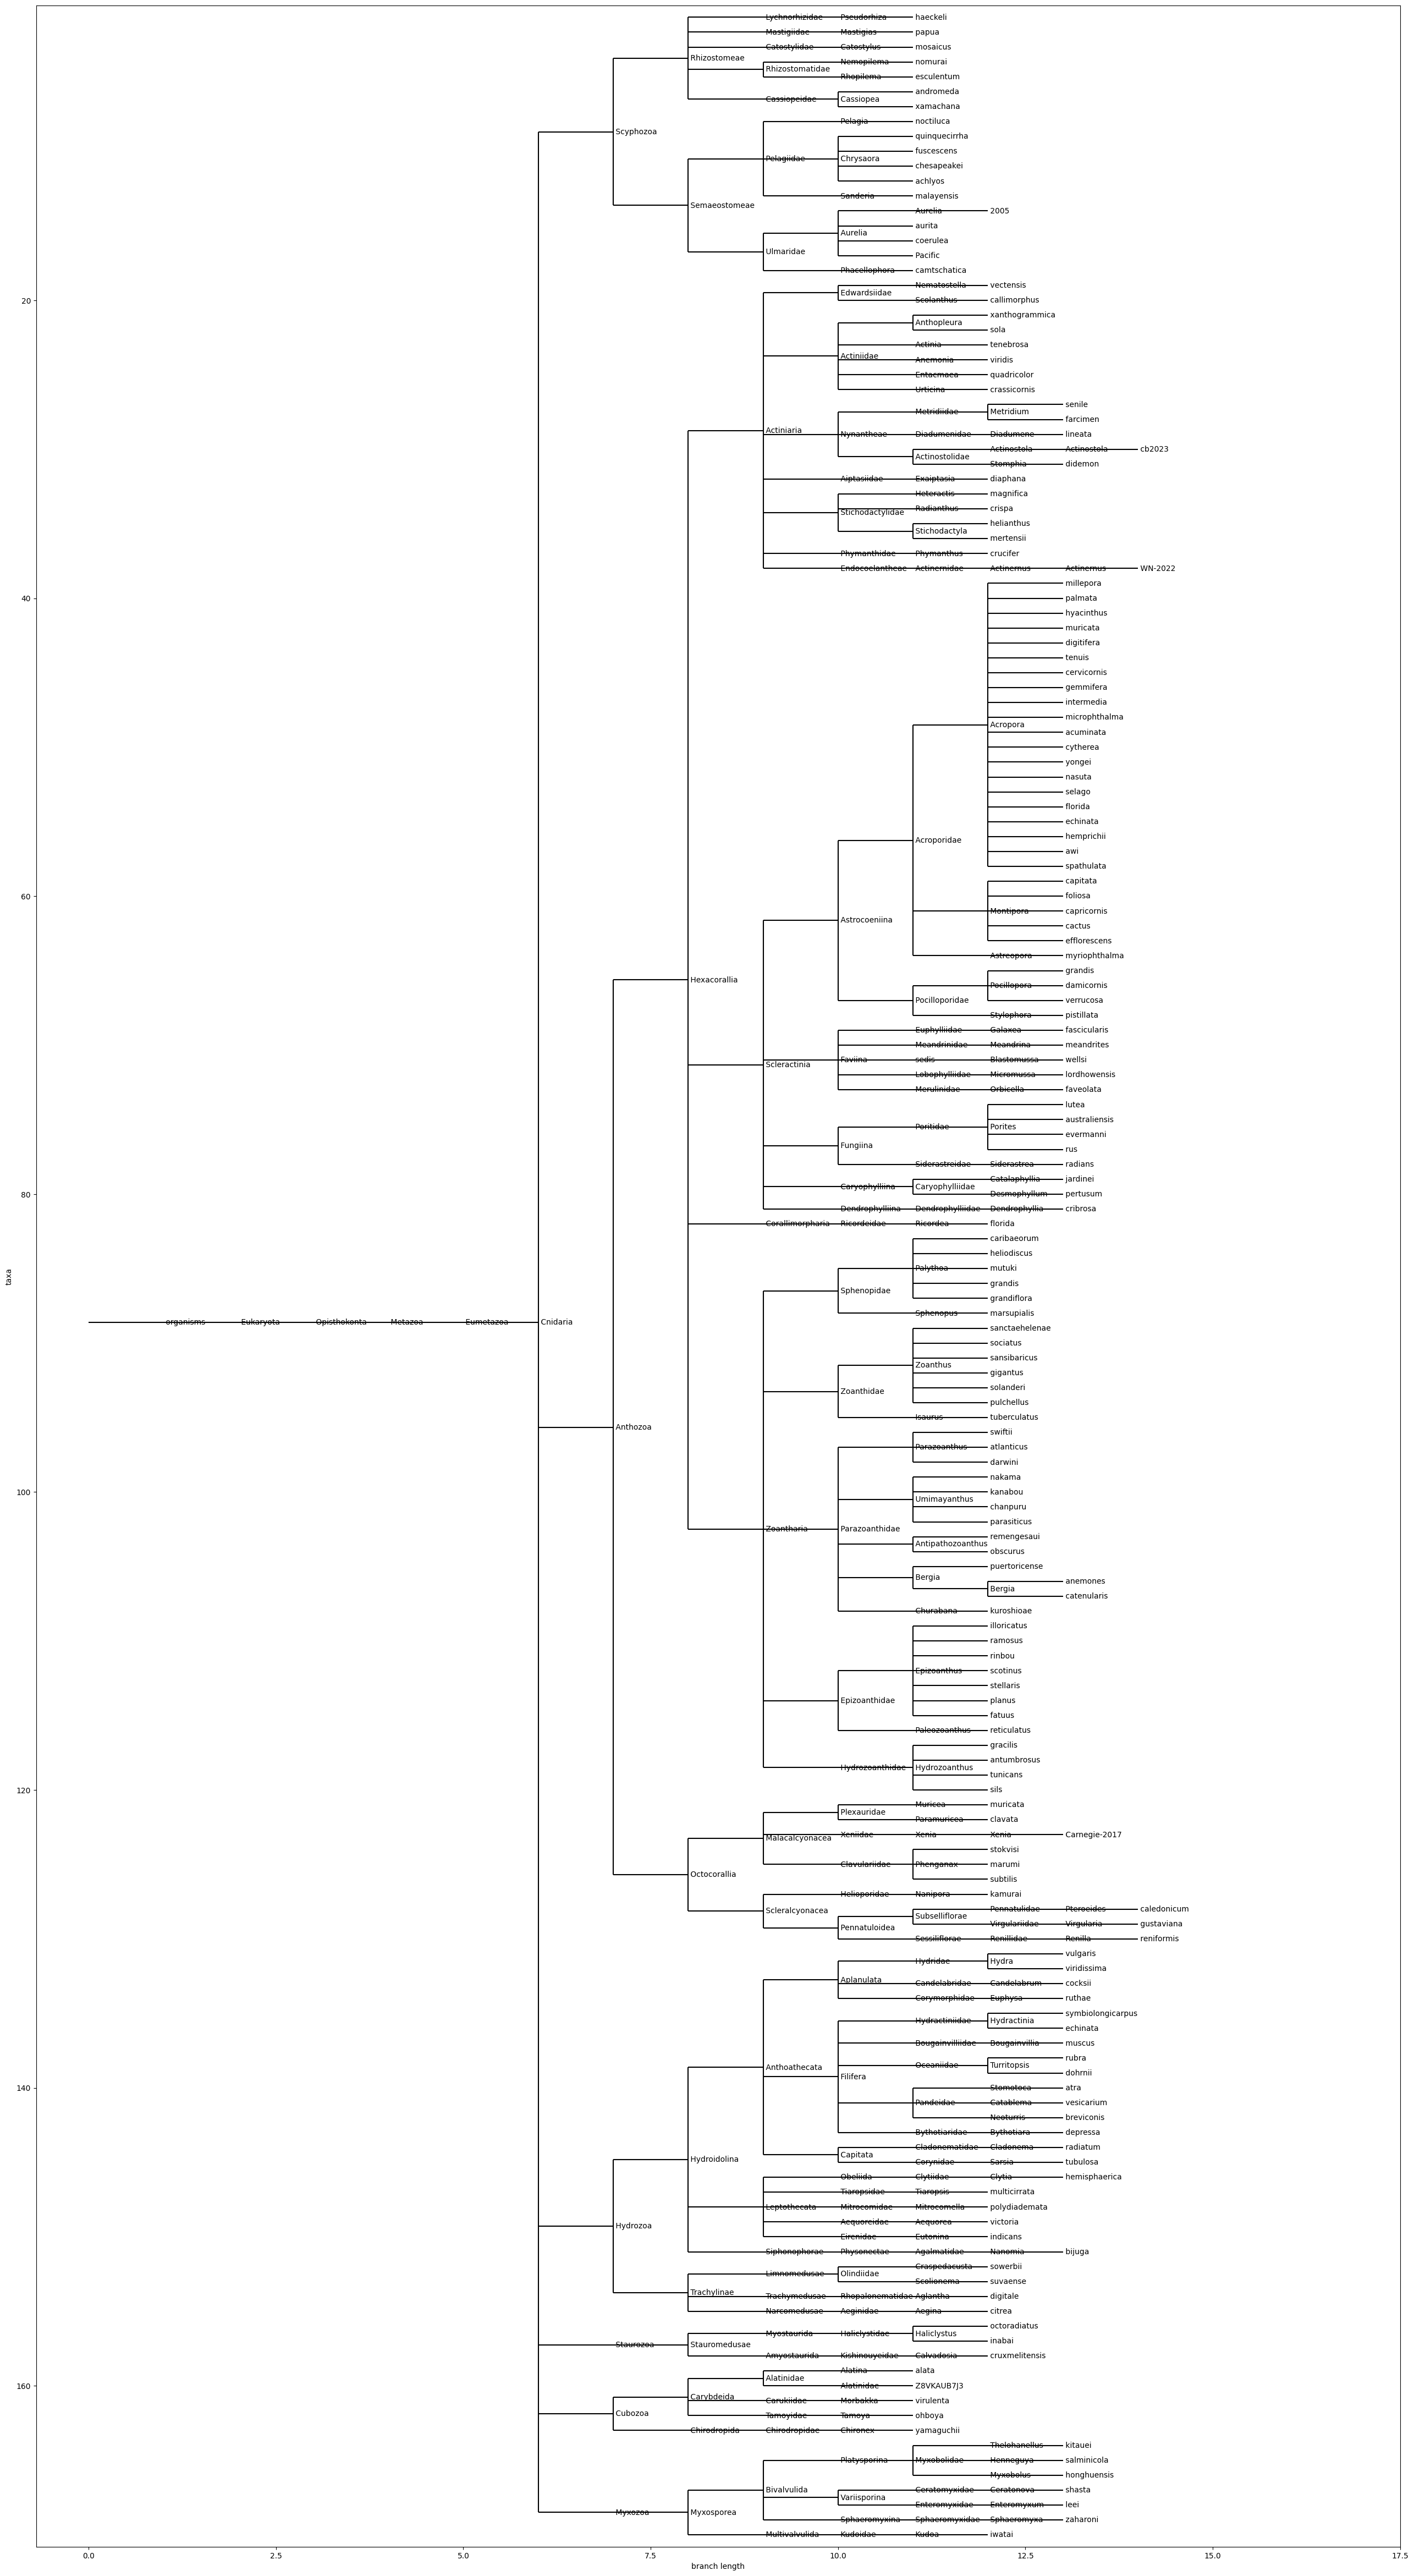

In [23]:
from Bio import Phylo
from io import StringIO
import matplotlib.pyplot as plt


# Parse the Newick string
tree = Phylo.read(StringIO(newick_tree), "newick")

# def simplify_tree_for_leaves(tree):
#     for clade in tree.find_clades():
#         if not clade.is_terminal():  # If it's an internal node
#             # Set branch lengths to a very small value (or zero)
#             clade.branch_length = 0.0001
#             # Remove or make labels empty for internal nodes
#             clade.name = None

# simplify_tree_for_leaves(tree)
fig = plt.figure(figsize=(8*4, 6*10))  

# Draw the tree on this figure
Phylo.draw(tree, do_show=False, axes=plt.gca())

# If you want to save the figure, do it before showing
plt.savefig('tree.svg', format="svg")

# Show the plot
plt.show()

In [5]:
!pip install ete3
!pip install PyQt5
!pip install QtPy

  Obtaining dependency information for PyQt5 from https://files.pythonhosted.org/packages/2f/e6/a1f9853e4933c312c6de9c79d126c7d92ef69ae0e53895fb1ceb0ecc77a6/PyQt5-5.15.10-cp37-abi3-manylinux_2_17_x86_64.whl.metadata
  Obtaining dependency information for PyQt5-sip<13,>=12.13 from https://files.pythonhosted.org/packages/ca/b0/5af957d148693e1d1b1e2e33c51dd9c8a3c29f7ac21008684d612c0b86c3/PyQt5_sip-12.13.0-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.whl.metadata
  Obtaining dependency information for PyQt5-Qt5>=5.15.2 from https://files.pythonhosted.org/packages/83/d4/241a6a518d0bcf0a9fcdcbad5edfed18d43e884317eab8d5230a2b27e206/PyQt5_Qt5-5.15.2-py3-none-manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 40.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 36.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.7/346.7 kB 28.8 MB/s eta 0:00:00
  Obtaining dependency information for QtPy 

In [25]:
%history -n -l 11


  14:
unique_species = df['Species_Name'].unique().tolist()
print(unique_species)
name2taxid = ncbi.get_name_translator(unique_species)

# Find common ancestor and construct the tree
taxids = [name2taxid[name][0] for name in unique_species if name in name2taxid]
tree = ncbi.get_topology(taxids)
for leaf in tree:
    # Fetch the scientific name for each taxid
    sci_name = ncbi.get_taxid_translator([leaf.name])[int(leaf.name)]
    # Set the leaf name to the scientific name
    leaf.name = sci_name

print(tree.write())
tree.write(outfile="/home/ilnitsky/gpfs/NPM/ncbi_blast_search/my_tree.newick")
  15:
from ete3 import NCBITaxa

ncbi = NCBITaxa()
  16:
unique_species = df['Species_Name'].unique().tolist()
print(unique_species)
name2taxid = ncbi.get_name_translator(unique_species)

# Find common ancestor and construct the tree
taxids = [name2taxid[name][0] for name in unique_species if name in name2taxid]
tree = ncbi.get_topology(taxids)
for leaf in tree:
    # Fetch the scientific name 

In [5]:
from ete3 import NCBITaxa

ncbi = NCBITaxa()

In [19]:
unique_species = df['Species_Name'].unique().tolist()
print(unique_species)
name2taxid = ncbi.get_name_translator(unique_species)

taxids = [name2taxid[name][0] for name in unique_species if name in name2taxid]
tree = ncbi.get_topology(taxids)
for leaf in tree:
    sci_name = ncbi.get_taxid_translator([leaf.name])[int(leaf.name)]
    leaf.name = sci_name

print(tree.write())
tree.write(outfile="/home/ilnitsky/gpfs/NPM/ncbi_blast_search/my_tree.newick")

['Hydra vulgaris', 'Hydractinia symbiolongicarpus', 'Dendronephthya gigantea', 'Acropora millepora', 'Acropora digitifera', 'Pocillopora damicornis', 'Orbicella faveolata', 'Desmophyllum pertusum', 'Actinia tenebrosa', 'Thelohanellus kitauei', 'Myxobolus squamalis', 'Paramuricea clavata', 'Henneguya salminicola', 'Nematostella vectensis', 'Exaiptasia diaphana', 'Porites evermanni', 'Porites lobata', 'Xenia sp. Carnegie-2017', 'Actinostola sp. cb2023', 'Stylophora pistillata', 'Pocillopora meandrina', 'Acropora cervicornis', 'Pocillopora verrucosa']
((((Nematostella vectensis:1,Exaiptasia diaphana:1,Actinia tenebrosa:1,Actinostola sp. cb2023:1)1:1,((((Pocillopora damicornis:1,Pocillopora meandrina:1,Pocillopora verrucosa:1)1:1,Stylophora pistillata:1)1:1,(Acropora millepora:1,Acropora cervicornis:1,Acropora digitifera:1)1:1)1:1,(Porites lobata:1,Porites evermanni:1)1:1,Desmophyllum pertusum:1,Orbicella faveolata:1)1:1)1:1,(Dendronephthya gigantea:1,Paramuricea clavata:1,Xenia sp. Carneg

In [7]:
%load_ext rpy2.ipython

In [8]:
%%R -i df
library(dplyr)
library(taxize)
library(ape)
library(ggtree)
# print(df)




[1] Accession_ID     Species_Name     N-terminal_found C-terminal_found
<0 rows> (or 0-length row.names)



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘ape’

The following object is masked from ‘package:dplyr’:

    where

Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.
ℹ invalid tbl_tree object. Missing column: label.
ℹ invalid tbl_tree object. Missing column: label.
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.


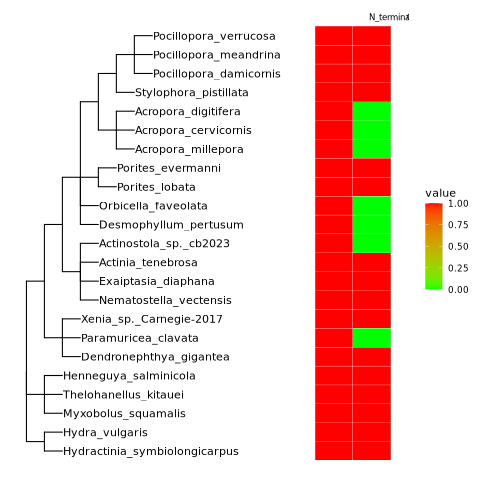

In [63]:
%%R -i df
df <- df[!duplicated(df$`Species_Name`), ]
df$Species_Name <- gsub(" ", "_", df$Species_Name)
df <- df %>% select(-Accession_ID)

# species_name <- as.list(df$Species_Name)
# n_terminal_found <- as.list(df$N_terminal_found)
# c_terminal_found <- as.list(df$C_terminal_found)

newick_tree <- "((((Nematostella vectensis:1,Exaiptasia diaphana:1,Actinia tenebrosa:1,Actinostola sp. cb2023:1)1:1,((((Pocillopora damicornis:1,Pocillopora meandrina:1,Pocillopora verrucosa:1)1:1,Stylophora pistillata:1)1:1,(Acropora millepora:1,Acropora cervicornis:1,Acropora digitifera:1)1:1)1:1,(Porites lobata:1,Porites evermanni:1)1:1,Desmophyllum pertusum:1,Orbicella faveolata:1)1:1)1:1,(Dendronephthya gigantea:1,Paramuricea clavata:1,Xenia sp. Carnegie-2017:1)1:1)1:1,(Hydractinia symbiolongicarpus:1,Hydra vulgaris:1)1:1,(Myxobolus squamalis:1,Thelohanellus kitauei:1,Henneguya salminicola:1)1:1);"
newick_tree <- gsub(" ", "_", newick_tree)
tree <- read.tree(text = newick_tree)

tree$tip.label

plotTree <- ggtree(tree)
plotTree + geom_tiplab()

rownames(df) <- df$Species_Name
df$Species_Name <- NULL

# # # # Read the Newick tree
# tree <- read.tree(text = newick_tree)


# # # # Ensure species names match exactly between the tree and the dataframe
# # # df$Species_Name <- gsub(" ", "_", df$Species_Name)

# # # # Prepare the tree object with ggtree
p <- ggtree(tree) + geom_tiplab()

# # # # Use gheatmap to add the heatmap to the tree
p <- gheatmap(p, df, offset=8, width=0.6, colnames_position="top", hjust=-0.5, font.size=3)

# # # # Adjust scales if necessary
p <- p + scale_x_ggtree() 

# # # # Print the plot
print(p)
# # df_unique
# # taxize::use_entrez()

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.
ℹ invalid tbl_tree object. Missing column: label.
ℹ invalid tbl_tree object. Missing column: label.
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.


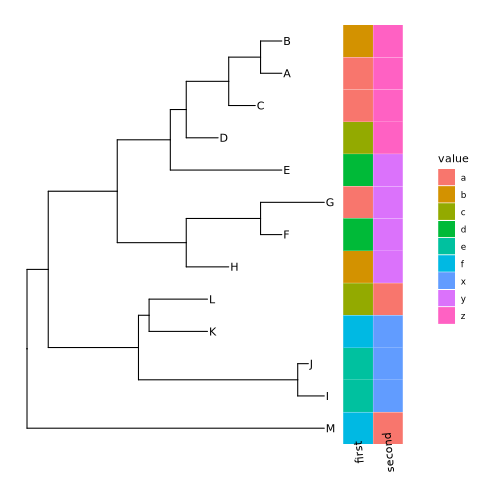

In [56]:
%%R -i df
# install.packages("remotes")
# if(!require("tidytree", quietly=TRUE))
# install_version("tidytree", version = "0.4.2")

nwk <- system.file("extdata", "sample.nwk", package="treeio")

tree <- read.tree(nwk)
circ <- ggtree(tree)
sessionInfo()
df <- data.frame(first=c("a", "b", "a", "c", "d", "d", "a", 
                        "b", "e", "e", "f", "c", "f"),
                 second= c("z", "z", "z", "z", "y", "y", 
                        "y", "y", "x", "x", "x", "a", "a"))
rownames(df) <- tree$tip.label

df2 <- as.data.frame(matrix(rnorm(39), ncol=3))
rownames(df2) <- tree$tip.label
colnames(df2) <- LETTERS[1:3]


gheatmap(circ, df, offset=.8, width=.2,
               colnames_angle=95, colnames_offset_y = .25)  + geom_tiplab()


# library(ggnewscale)
# p2 <- p1 + new_scale_fill()
# gheatmap(p2, df2, offset=15, width=.3,
#          colnames_angle=90, colnames_offset_y = .25) 